# Customer Segmentation

Unsupervised learning project to segment mall customers into groups based on their **Annual Income** and **Spending Score**, using KMeans and DBSCAN.

## 1. Imports & Data Loading

Make sure `data/Mall_Customers.csv` exists (see `data/README.md` for download instructions).

In [14]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [15]:
from src.data.load_data import load_data, preprocess, scale_features
from src.visualization.eda_plots import plot_distributions, plot_income_vs_spending, plot_clusters
from src.models.train_models import elbow_method, run_kmeans, run_dbscan, evaluate_clustering
from src.utils.config import load_config

import pandas as pd

config = load_config()


In [16]:
df = load_data(config["data"]["raw_path"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## 2. Preprocessing

Drop the `CustomerID` column (not useful for clustering) and encode `Gender`/`Genre` numerically.

In [17]:
df = preprocess(df)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis

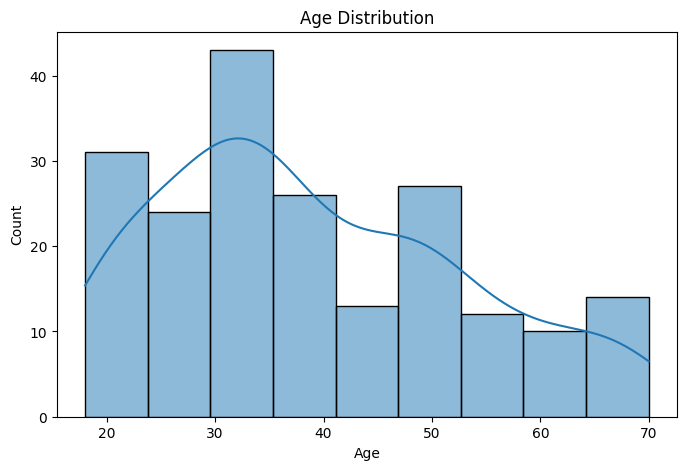

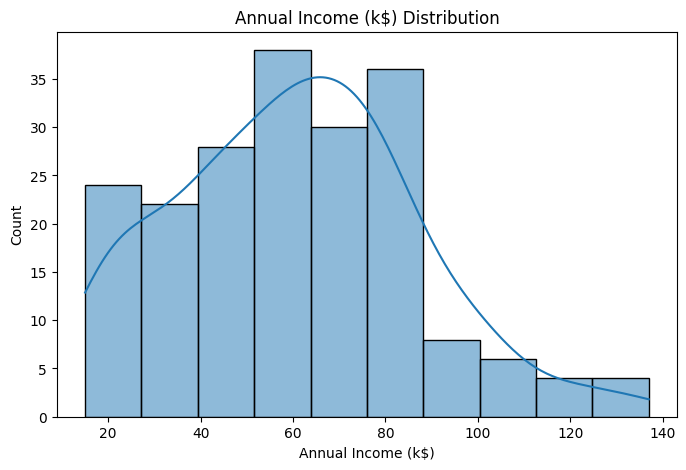

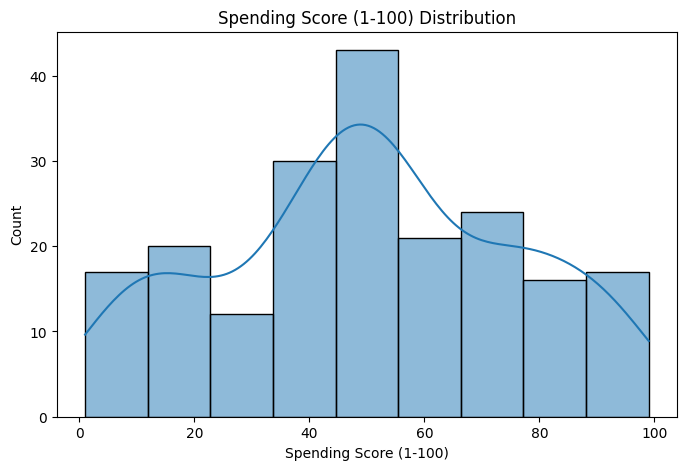

In [18]:
plot_distributions(df, ["Age", "Annual Income (k$)", "Spending Score (1-100)"])

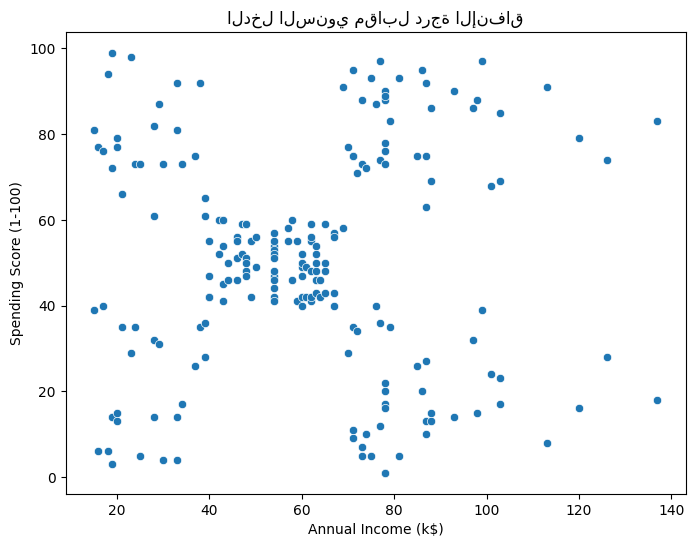

In [19]:
plot_income_vs_spending(df)

## 4. Feature Scaling

We cluster on `Annual Income` and `Spending Score`, the two features that best separate distinct customer groups visually.

In [20]:
FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]
X_scaled, scaler = scale_features(df, FEATURES)
X_scaled[:5]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 5. Choosing K: Elbow Method

We plot inertia across a range of K values to visually identify the 'elbow' point — a good trade-off between cluster compactness and simplicity.

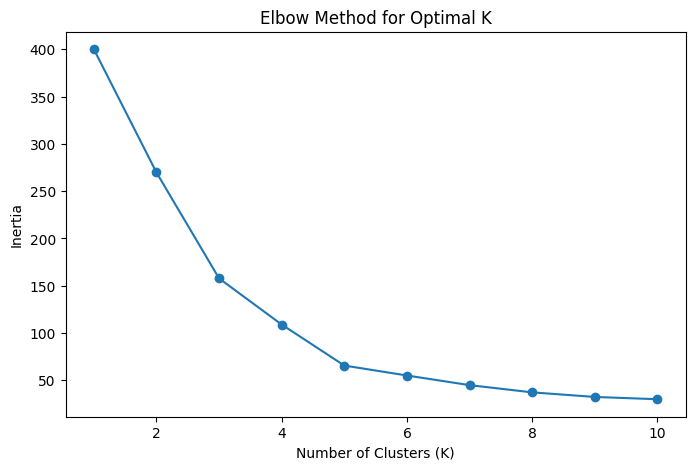

In [21]:
inertias = elbow_method(X_scaled)

## 6. KMeans Clustering

Based on the elbow plot and the visual scatter of Income vs. Spending Score, 5 clusters is a natural choice for this dataset.

In [22]:
kmeans_labels, kmeans_model = run_kmeans(X_scaled, n_clusters=5)
df["KMeans_Labels"] = kmeans_labels

kmeans_silhouette = evaluate_clustering(X_scaled, kmeans_labels)
print(f"KMeans silhouette score: {kmeans_silhouette:.4f}")


KMeans silhouette score: 0.5547


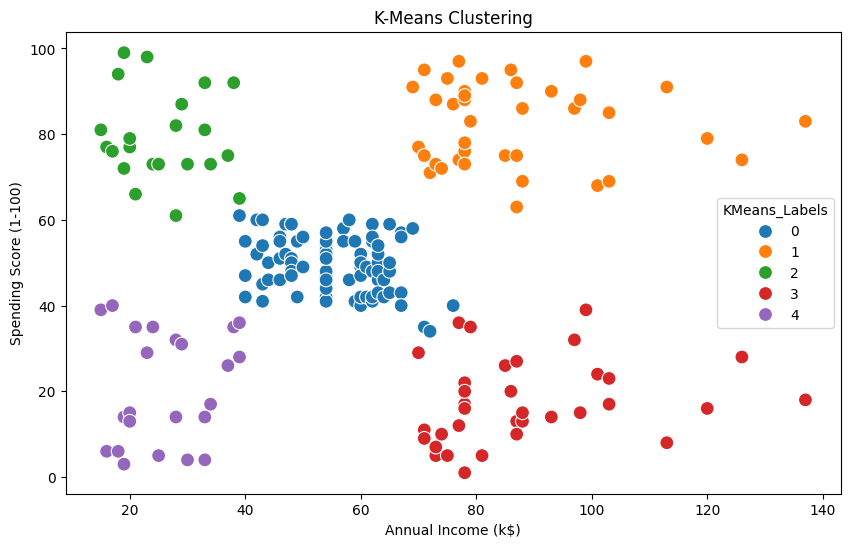

In [23]:
plot_clusters(df, hue_col="KMeans_Labels", title="K-Means Clustering")

## 7. DBSCAN Clustering

Unlike KMeans, DBSCAN doesn't require specifying the number of clusters upfront, and can flag outliers as noise (label `-1`).

In [24]:
dbscan_labels, dbscan_model = run_dbscan(X_scaled, eps=0.3, min_samples=5)
df["DBSCAN_Labels"] = dbscan_labels

dbscan_silhouette = evaluate_clustering(X_scaled, dbscan_labels)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN silhouette score: {dbscan_silhouette}")
print(f"Noise points: {n_noise} / {len(dbscan_labels)}")


DBSCAN silhouette score: 0.31614121976731185
Noise points: 35 / 200


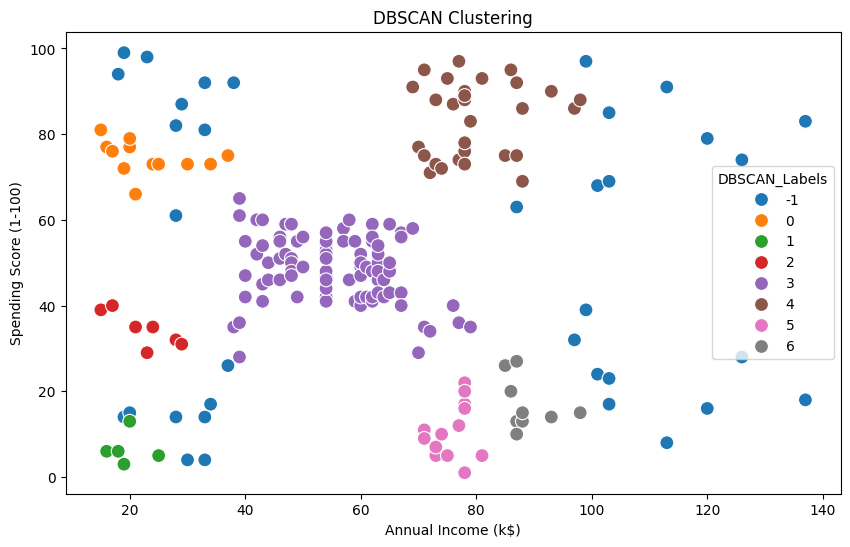

In [25]:
plot_clusters(df, hue_col="DBSCAN_Labels", title="DBSCAN Clustering")

## 8. KMeans vs. DBSCAN

- **KMeans** requires choosing K upfront but produces clean, evenly-shaped clusters — well suited to this dataset's fairly distinct groupings.
- **DBSCAN** doesn't require K, and naturally identifies outliers as noise, but is sensitive to the `eps` and `min_samples` parameters — poorly tuned values can classify too many (or too few) points as noise.

For this dataset, KMeans tends to produce more interpretable, business-friendly segments (e.g. "high income, low spending" or "low income, high spending").


## Conclusion

Both clustering approaches reveal distinct customer segments based on income and spending behavior. These segments can inform targeted marketing strategies — for example, offering loyalty perks to high-income/high-spending customers, or targeted discounts to high-income/low-spending customers who aren't currently engaged.